# Preparing the data for training the Machine Learning Model

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report, ConfusionMatrixDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import chi2_contingency


sns.set_style('ticks')
pd.set_option('display.max_columns', 100)

df = pd.read_csv('cleaned_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   Tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [2]:
# Categorizing TotalCharges, MonthlyCharges, Tenure columns
# The reason for this is that we'll be using Chi-square goodness of fit for selecting independent variables.
# Since this test has assumption of categorical independent variables, then we must categorize the variables.
# We'll use quartiles for reasonable categorization.
ColumnsCategorize = ['TotalCharges', 'MonthlyCharges', 'Tenure']

for col in ColumnsCategorize:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    df[col] = pd.cut(df[col], bins=[-np.inf, q1, q3, np.inf], labels=[f'{str(col)}Low', f'{str(col)}Medium', f'{str(col)}High'])
    print(df[col].value_counts()) # Sanity check
    print(f'Total count: {df[col].size}\n')  # Sanity check

TotalCharges
TotalChargesMedium    3520
TotalChargesLow       1762
TotalChargesHigh      1761
Name: count, dtype: int64
Total count: 7043

MonthlyCharges
MonthlyChargesMedium    3523
MonthlyChargesLow       1762
MonthlyChargesHigh      1758
Name: count, dtype: int64
Total count: 7043

Tenure
TenureMedium    3434
TenureLow       1854
TenureHigh      1755
Name: count, dtype: int64
Total count: 7043



In [3]:
# Perform Chi-Square Goodness of Fit test for all independent variable with Churn column as dependent variable.
# Null Hypothesis: The two variables are independent of each other.
# Alternative Hypothesis: The two variables are dependent on each other.

predictors = df.drop(columns='Churn').columns

chi_scores = pd.DataFrame(columns=['IndependentVariable','chi_statistic', 'p_value'],
                          index=range(len(predictors)))
for i,X in enumerate(predictors):
    contingency_table = pd.crosstab(df[X], df['Churn'])
    chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table)
    chi_scores.loc[i, 'IndependentVariable'] = X
    chi_scores.loc[i, 'chi_statistic'] = chi2_statistic
    chi_scores.loc[i, 'p_value'] = p_value
chi_scores.sort_values(by='p_value', ascending=False)

# As observed, columns Gender, PhoneService has p-value > 0.05, there is no enough proof to say that these have significant relationship with Churn.
# drop columns: Gender, PhoneService since they don't have significant relationship with Churn.

,IndependentVariable,chi_statistic,p_value
0,Gender,0.484083,0.486579
5,PhoneService,0.915033,0.338783
6,MultipleLines,11.330441,0.003464
2,Partner,158.733382,0.0
1,SeniorCitizen,159.4263,0.0
3,Dependents,189.129249,0.0
15,PaperlessBilling,258.277649,0.0
17,MonthlyCharges,284.227322,0.0
12,StreamingTV,374.203943,0.0
13,StreamingMovies,375.661479,0.0


In [4]:
# Dropping Gender, PhoneService columns
df = df.drop(['Gender', 'PhoneService'], axis=1).copy()

In [5]:
# Convert categorical inputs into numerical equivalent in preparation for VIF Test
columns_yes_no = ['Partner', 'Dependents', 
            'PaperlessBilling', 'Churn']
for col in columns_yes_no:
    df[col] = df[col].map({'Yes':1, 'No':0})

columns001 = ['OnlineSecurity','OnlineBackup','DeviceProtection',
              'TechSupport','StreamingTV','StreamingMovies',]
for col in columns001:
    df[col] = df[col].map({'Yes':1, 'No':0, 'No internet service':0})

df['MultipleLines'] = df['MultipleLines'].map({'Yes':1, 'No':0, 'No phone service':0})
df['InternetService'] = df['InternetService'].map({'No':0, 'Fiber optic':2, 'DSL':1})

df['PaymentMethod'] = df['PaymentMethod'].map({'Bank transfer (automatic)':1, 'Credit card (automatic)':1,
                                               'Electronic check':0, 'Mailed check':0})
df['Contract'] = df['Contract'].map({'Month-to-month':1, 'One year':12, 'Two year':24}) # use month as unit

In [6]:
# Check the unique elements for each columns
for col in df.columns:
    print(f'The unique elements for column {col} are: \n {df[col].unique()}\n')

The unique elements for column SeniorCitizen are: 
 [0 1]

The unique elements for column Partner are: 
 [1 0]

The unique elements for column Dependents are: 
 [0 1]

The unique elements for column Tenure are: 
 ['TenureLow', 'TenureMedium', 'TenureHigh']
Categories (3, object): ['TenureLow' < 'TenureMedium' < 'TenureHigh']

The unique elements for column MultipleLines are: 
 [0 1]

The unique elements for column InternetService are: 
 [1 2 0]

The unique elements for column OnlineSecurity are: 
 [0 1]

The unique elements for column OnlineBackup are: 
 [1 0]

The unique elements for column DeviceProtection are: 
 [0 1]

The unique elements for column TechSupport are: 
 [0 1]

The unique elements for column StreamingTV are: 
 [0 1]

The unique elements for column StreamingMovies are: 
 [0 1]

The unique elements for column Contract are: 
 [ 1 12 24]

The unique elements for column PaperlessBilling are: 
 [1 0]

The unique elements for column PaymentMethod are: 
 [0 1]

The unique elem

In [7]:
# Check for VIF
MonthlyChargesDummy = pd.get_dummies(df['MonthlyCharges'],drop_first=True).astype('int')
TotalChargesDummy = pd.get_dummies(df['TotalCharges'],drop_first=True).astype('int')
TenureDummy = pd.get_dummies(df['Tenure'],drop_first=True).astype('int')

#Drop Tenure, MonthlyCharges, and TotalCharges columns since we created dummy variable for these columns
df_vif_test = df.drop(columns=['Churn', 'MonthlyCharges',
                               'TotalCharges', 'Tenure'])
df_vif_test = pd.concat([df_vif_test,
                        MonthlyChargesDummy,
                        TotalChargesDummy,
                        TenureDummy], axis=1)


X_const = add_constant(df_vif_test)

vif_test = pd.DataFrame()
vif_test['feature'] = X_const.columns
vif_test['VIF_value'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

# print(vif_test.sort_values(by='VIF_value'))
vif_test.sort_values(by='VIF_value', ascending=False)

# Since MonthlyCharges and TotalCharges has linear relationship (direct relationship) it makes sense that they have high VIF_value
# TotalCharges also has relationship with Tenure, we shall remove this column (the column containing dummy variables of TotalCharges) so that Tenure column remains.
# REMOVE: TotalCharges

,feature,VIF_value
16,MonthlyChargesHigh,10.894420
0,const,10.018488
18,TotalChargesHigh,6.713703
15,MonthlyChargesMedium,6.499524
20,TenureHigh,5.451349
5,InternetService,5.140489
17,TotalChargesMedium,4.175974
19,TenureMedium,3.907909
12,Contract,2.264767
10,StreamingTV,1.867956


In [8]:
df_vif_test2 = df.drop(columns=['Churn', 'MonthlyCharges', 'TotalCharges', 'Tenure'])
df_vif_test2 = pd.concat([df_vif_test2,
                        MonthlyChargesDummy,
                        TenureDummy], axis=1)

X_const2 = add_constant(df_vif_test2)

vif_test2 = pd.DataFrame()
vif_test2['feature'] = X_const2.columns
vif_test2['VIF_value'] = [variance_inflation_factor(X_const2.values, i) for i in range(X_const2.shape[1])]

# print(vif_test2.sort_values(by='VIF_value'))
vif_test2.sort_values(by='VIF_value', ascending=False)
# as can be observed, all of the features has VIF value < 5, except MonthlyChargesHigh and MonthlyChargesMedium.
# We'll only remove MonthlyChargesMedium column for this.
# (UPDATE THIS NOTE, REFER TO NEXT PAGE FOR UPDATES)

,feature,VIF_value
16,MonthlyChargesHigh,10.874749
0,const,9.568190
15,MonthlyChargesMedium,6.409467
5,InternetService,4.977526
18,TenureHigh,3.223765
12,Contract,2.230758
10,StreamingTV,1.851646
17,TenureMedium,1.844782
11,StreamingMovies,1.839473
8,DeviceProtection,1.483200


In [9]:
df_vif_test3 = df_vif_test2.drop(columns='MonthlyChargesMedium')# REMOVE MonthlyChargesMedium instead of MonthlyChargesHigh 
# so that it takes yes if high amount and no otherwise, problematic if we drop MonthlyChargesHigh

X_const3 = add_constant(df_vif_test3)
vif_test3 = pd.DataFrame()
vif_test3['feature'] = X_const3.columns
vif_test3['VIF_value'] = [variance_inflation_factor(X_const3.values, i) for i in range(X_const3.shape[1])]

vif_test3.sort_values(by='VIF_value', ascending=False)
# Finally, all VIF values are less than 5, implying that the following predictor variables has little to no correlation with each other.

,feature,VIF_value
0,const,9.136837
17,TenureHigh,3.220627
5,InternetService,2.244575
12,Contract,2.209077
15,MonthlyChargesHigh,2.154308
16,TenureMedium,1.843997
10,StreamingTV,1.755191
11,StreamingMovies,1.752908
8,DeviceProtection,1.446034
2,Partner,1.445360


In [10]:
# data preparation for machine learning

df_vif_test3['Churn'] = df['Churn'] # add Churn column from the original df
X = df_vif_test3.drop(columns='Churn')
y = df_vif_test3['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=16)

NOTE: No = 0, Yes = 1
Churn
0    73.463013
1    26.536987
Name: count, dtype: float64


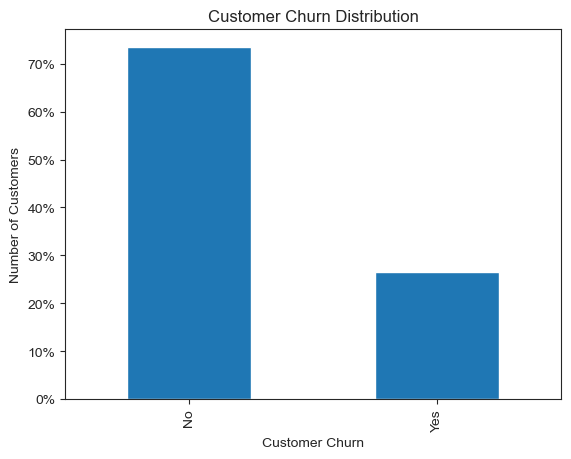

In [11]:
#Check how many customers churns or not in this dataset:

churn_plot = df['Churn'].value_counts().copy()
churn_plot = churn_plot * 100/7043 # get the percentage form
print(f'NOTE: No = 0, Yes = 1\n{churn_plot}')

#Visualize the data
churn_plot.index = ['No', 'Yes']
fig, ax = plt.subplots(1,1)
churn_plot.plot(kind='bar', title='Customer Churn Distribution')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'{int(y)}%'))
plt.ylabel('Number of Customers')
plt.xlabel('Customer Churn')
plt.show()

In [42]:
# create baseline model for evaluation:

model_base = LogisticRegression(class_weight='balanced')
model_base.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [13]:
# Evaluation metrics:

y_pred_base = model_base.predict(X_test)
accuracy_base = accuracy_score(y_test, y_pred_base)
recall_base = recall_score(y_test, y_pred_base)
precision_base = precision_score(y_test, y_pred_base)

print(f'Accuracy score is: {accuracy_base}')
print(f'Recall score is: {recall_base}')
print(f'Precision score is: {precision_base}')

Accuracy score is: 0.7345635202271115
Recall score is: 0.8128491620111732
Precision score is: 0.4866220735785953


In [43]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_base = cross_val_score(model_base, X, y, cv=skf, scoring='recall')

print("Stratified CV scores:", scores_base)
print("Mean recall:", scores_base.mean())

Stratified CV scores: [0.80748663 0.8342246  0.80748663 0.77747989 0.79679144]
Mean accuracy: 0.8046938395148457


In [14]:
print(classification_report(y_test, y_pred_base))

              precision    recall  f1-score   support

           0       0.92      0.71      0.80      1051
           1       0.49      0.81      0.61       358

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.81      0.73      0.75      1409



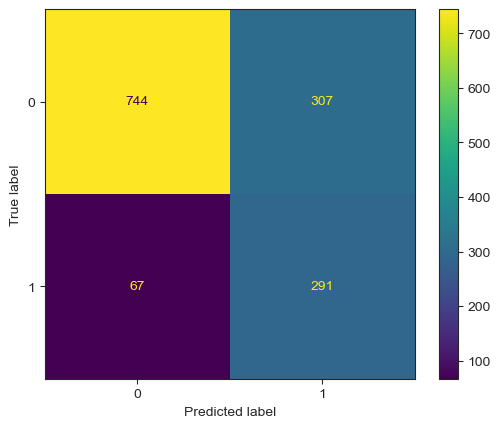

In [15]:
# Plot the confusion matrix of the prediction

cm_base = confusion_matrix(y_test, y_pred_base)
ConfusionMatrixDisplay(cm_base).plot()
plt.show()

In [47]:
#Hyperparameter tuning using GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_iter':[100,200],
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'solver':['liblinear', 'saga']

}
model2 = GridSearchCV(estimator=model_base,
                      param_grid=param_grid,
                      scoring='recall',
                      verbose=1,
                      n_jobs=-1)

#Fit the model
model2.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(estimator=LogisticRegression(class_weight='balanced'), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000],
                         'max_iter': [100, 200],
                         'solver': ['liblinear', 'saga']},
             scoring='recall', verbose=1)

In [48]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores2 = cross_val_score(model2, X, y, cv=skf, scoring='recall')

print("Stratified CV scores:", scores2)
print("Mean recall:", scores2.mean())

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Stratified CV scores: [0.81818182 0.84491979 0.8315508  0.80697051 0.81283422]
Mean recall: 0.8228914280798841


In [54]:
y_pred2 = model2.predict(X_test)
print('Accuracy score: ', accuracy_score(y_test, y_pred2))
print('Recall score: ', recall_score(y_test, y_pred2))
print('Precision score: ', precision_score(y_test, y_pred2))

Accuracy score:  0.7246273953158269
Recall score:  0.8491620111731844
Precision score:  0.47648902821316613


In [55]:
# Results
print("Best Parameters:", model2.best_params_)
print("Best Score:", model2.best_score_)
accuracy_score(y_test, y_pred2)

print(classification_report(y_test, y_pred2))

Best Parameters: {'C': 0.01, 'max_iter': 100, 'solver': 'saga'}
Best Score: 0.8153585557231219
              precision    recall  f1-score   support

           0       0.93      0.68      0.79      1051
           1       0.48      0.85      0.61       358

    accuracy                           0.72      1409
   macro avg       0.70      0.77      0.70      1409
weighted avg       0.81      0.72      0.74      1409



In [113]:
#model interpretation enhancement

from sklearn.metrics import precision_recall_curve, auc

y_scores = model2.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
pr_auc = auc(recall, precision)

print(f"Precision-Recall AUC: {pr_auc:.4f}")

Precision-Recall AUC: 0.6152


In [114]:
threshold = 0.5
y_pred3 = (y_scores >= threshold).astype(int)
print(classification_report(y_test, y_pred3))
print("Accuracy: ",accuracy_score(y_test, y_pred3))
print("Recall: ",recall_score(y_test, y_pred3))

              precision    recall  f1-score   support

           0       0.93      0.68      0.79      1051
           1       0.48      0.85      0.61       358

    accuracy                           0.72      1409
   macro avg       0.70      0.77      0.70      1409
weighted avg       0.81      0.72      0.74      1409

Accuracy:  0.7246273953158269
Recall:  0.8491620111731844


In [108]:
recall_score(y_test, y_pred3)

0.7430167597765364

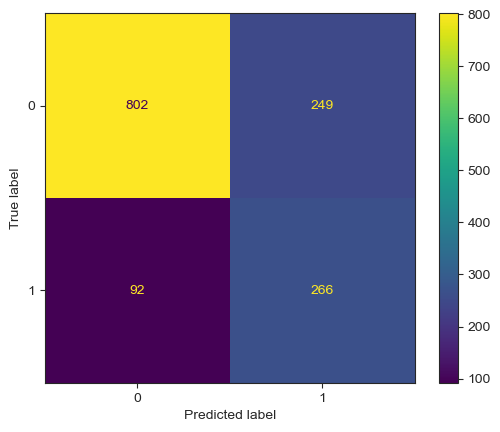

In [ ]:
cm3 = confusion_matrix(y_test, y_pred3)
ConfusionMatrixDisplay(cm3).plot()
plt.show()

# Use this if false positives are costly (i.e. We want to catch churners but not that much since churn rate is within the normal range)

In [22]:
# Hyperparameter tuning (2) using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'max_iter':[100,200,1000],
    'C': np.logspace(-4,4,100),
    'penalty': ['l1', 'l2'],
    'solver':['liblinear', 'saga']
}
random_search_model = RandomizedSearchCV(
    estimator = model_base,
    param_distributions = param_dist,
    n_iter = 500,
    scoring = 'recall',
    random_state = 16,
    n_jobs = -1)

#Fit the model
random_search_model.fit(X_train, y_train)

RandomizedSearchCV(estimator=LogisticRegression(class_weight='balanced'),
                   n_iter=500, n_jobs=-1,
                   param_distributions={'C': array([1.00000000e-04, 1.20450354e-04, 1.45082878e-04, 1.74752840e-04,
       2.10490414e-04, 2.53536449e-04, 3.05385551e-04, 3.67837977e-04,
       4.43062146e-04, 5.33669923e-04, 6.42807312e-04, 7.74263683e-04,
       9.32603347e-04, 1.12332403e-03, 1.35304777e-03...
       6.13590727e+02, 7.39072203e+02, 8.90215085e+02, 1.07226722e+03,
       1.29154967e+03, 1.55567614e+03, 1.87381742e+03, 2.25701972e+03,
       2.71858824e+03, 3.27454916e+03, 3.94420606e+03, 4.75081016e+03,
       5.72236766e+03, 6.89261210e+03, 8.30217568e+03, 1.00000000e+04]),
                                        'max_iter': [100, 200, 1000],
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear', 'saga']},
                   random_state=16, scoring='recall')

In [50]:
#Print results
print('Best Parameters: ', random_search_model.best_params_)
print('Best CV Score: ', random_search_model.best_score_)
print('Accuracy (Recall): ', random_search_model.score(X_test,y_test))

Best Parameters:  {'solver': 'saga', 'penalty': 'l1', 'max_iter': 100, 'C': 0.0001}
Best CV Score:  1.0
Accuracy (Recall):  0.9022346368715084


In [52]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores3 = cross_val_score(random_search_model, X, y, cv=skf, scoring='recall')

print("Stratified CV scores:", scores3)
print("Mean recall:", scores3.mean())

Stratified CV scores: [0.89304813 0.89037433 0.89037433 0.87935657 0.87433155]
Mean recall: 0.8854969821221201


In [61]:
y_pred4 = random_search_model.predict(X_test)
print('Accuracy score: ', accuracy_score(y_test, y_pred4))
print('Recall score: ', recall_score(y_test, y_pred4))
print('Precision score: ', precision_score(y_test, y_pred4))

Accuracy score:  0.652235628105039
Recall score:  0.9022346368715084
Precision score:  0.41516709511568123


In [117]:
y_pred5 = random_search_model.predict_proba(X_test)[:, 1]
y_scores2 = (y_pred5 >= 0.5).astype(int)
print(classification_report(y_test, y_scores2))

              precision    recall  f1-score   support

           0       0.94      0.57      0.71      1051
           1       0.42      0.90      0.57       358

    accuracy                           0.65      1409
   macro avg       0.68      0.73      0.64      1409
weighted avg       0.81      0.65      0.67      1409



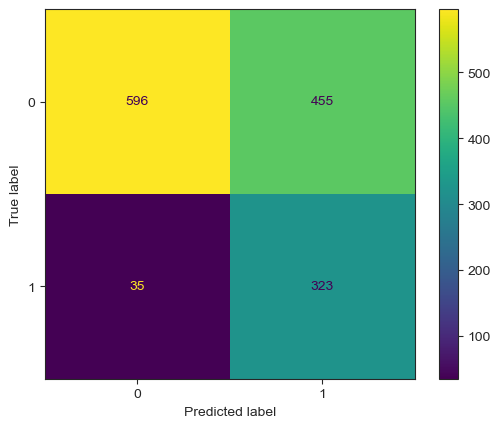

In [ ]:
cm_2 = confusion_matrix(y_test, y_pred4)
ConfusionMatrixDisplay(cm_2).plot()
plt.show()

# We use this if we are not that conservative when it comes to false positives (i.e. Save churners as possible)